In [30]:
#import liobrary
import pandas as pd

In [31]:
#read Text File
df = pd.read_csv("mabel.txt",header=None,on_bad_lines='skip',encoding='utf8')

In [32]:
#remove unwanted first row
df=df.drop(0)
#sets column names
df.columns=['Date','Chat']
#split the chat message till '-'
Message=df["Chat"].str.split("-",n=1,expand=True)
#Assign a name to 0th column
df["Time"]=Message[0]
##split the chat message till ':'
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
#Now the dataset has 4 columns
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [4]:
y#import library for preprocess technique(CountVector)
from sklearn.feature_extraction.text import CountVectorizer
#import library for topic_modeling_algorithm  LDA
from sklearn.decomposition import LatentDirichletAllocation

In [6]:
#Model creation for count vector
count_vector= CountVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=count_vector.fit_transform(df["Chat"])

In [7]:
##Model creation for LDA
lda_model=LatentDirichletAllocation(n_components=2,random_state=42)
lda_model.fit(dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [9]:
#gives topic proabilties
topic_results=lda_model.transform(dtm)
#select best topic per document
df["Topic"]=topic_results.argmax(axis=1)


In [23]:
#index=>topic number(0,1,2),topic=>weights(proability) of words in that topic
#Row=one topic,column=>proability of paticular word
for index,topic in enumerate(lda_model.components_):
    #gives all words in our vocabulary 
    #argsort return index of 10 highest proability elements in ascendind order
    results=([count_vector.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['meeting', 'ml', 'start', 'abstracts', 'church', 'office', 'send', 'vignesh', 'hi', 'tomorrow']
['abstract', 'read', 'ask', 'share', 'send', 'number', 'need', 'details', 'ok', 'mam']


In [24]:
df

,Date,Time,Name,Chat,Topic
0,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,0
1,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,0
2,05/12/19,1:42 pm,AR❤,Ramisha Rani K,1
3,05/12/19,1:42 pm,Mabel Infoziant,Ok,1
4,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,0
5,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,0
6,05/12/19,1:43 pm,AR❤,Yes Mam,1
7,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,0
8,05/12/19,1:43 pm,AR❤,Yeah mam,1
9,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,0


In [25]:
df["Topic"].value_counts()

Topic
1    27
0    23
Name: count, dtype: int64

In [26]:
#!pip install wordCloud

In [27]:
dataset=df

In [28]:
#create visual words
from wordcloud import WordCloud
#remove stop words
from nltk.corpus import stopwords
#nltk means natual language toolkit
import nltk
#disply image
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jegat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

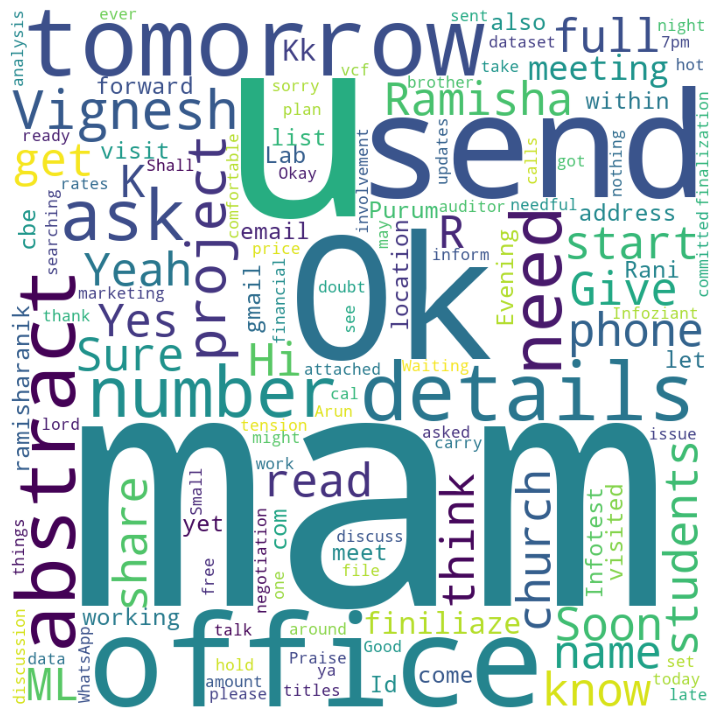

Successfully created


In [29]:
#collect all chat text
comment_words = []
stoplist = stopwords.words('english')
#Remove unwanted words
stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
wordcloudss="This function saves image"
dataset.index=range(dataset.shape[0])
for i in range(1,len(dataset)): 
    comment_words.append(dataset['Chat'][i])
    #combine all msg into one big text
    vv=" ".join(comment_words)          
    #wordcount=>howmany times the word appear
    #Bigger values are clear,higher resolution.Displys most frequented words  BIGGER.
    #SMALLER words =Less Frequent
    wordcloud = WordCloud(width = 800, height = 800, 
                                background_color ='white', 
                                      stopwords = stoplist, 
                                      min_font_size = 10).generate(vv)         
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
#Save the image
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"
